# Take Home Test — Data Analyst
## E-Commerce Electronics Store: Conversion Funnel & Customer Behavior Analysis

**Dataset:** Ecommerce Events History in Electronics Store (Kaggle) — `events.csv`
885,129 baris event (view/cart/purchase) dari Sept 2020 – Feb 2021.

---

## Tahap 1: Problem Statement & Tujuan Analisis

### Problem Statement
Toko elektronik online ini mencatat jutaan interaksi pengguna (view, add-to-cart, purchase),
namun hanya sebagian kecil yang berujung pada pembelian. Manajemen ingin memahami:

1. **Seberapa besar tingkat konversi** dari view → cart → purchase, dan di titik mana
   pengguna paling banyak "bocor" dari funnel?
2. **Kategori produk dan brand apa** yang paling berkontribusi terhadap purchase dan revenue?
3. **Faktor apa** (harga, waktu, kategori) yang memengaruhi keputusan pengguna untuk
   menyelesaikan pembelian atau meninggalkan cart (cart abandonment)?
4. **Kapan** (jam, hari, bulan) aktivitas dan pembelian pengguna paling tinggi?

### Tujuan Analisis
- Mengukur funnel konversi (view → cart → purchase) dan tingkat cart abandonment.
- Mengidentifikasi kategori & brand dengan kontribusi purchase/revenue tertinggi.
- Menganalisis pengaruh harga terhadap keputusan checkout.
- Menemukan pola waktu (jam/hari/bulan) untuk mendukung strategi promosi & stok.
- Menghasilkan rekomendasi bisnis berbasis data untuk meningkatkan konversi dan revenue.


## Tahap 2: Data Preprocessing

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10,5)

df = pd.read_csv('events.csv')
print('Shape awal:', df.shape)
df.head()


Shape awal: (79723, 9)


,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2020-09-24 11:57:06 UTC,view,1996170,2144415922528452715,electronics.telephone,NaN,31.90,1.515916e+18,LJuJVLEjPT
1,2020-09-24 11:57:26 UTC,view,139905,2144415926932472027,computers.components.cooler,zalman,17.16,1.515916e+18,tdicluNnRY
2,2020-09-24 11:57:27 UTC,view,215454,2144415927158964449,NaN,NaN,9.81,1.515916e+18,4TMArHtXQy
3,2020-09-24 11:57:33 UTC,view,635807,2144415923107266682,computers.peripherals.printer,pantum,113.81,1.515916e+18,aGFYrNgC08
4,2020-09-24 11:57:36 UTC,view,3658723,2144415921169498184,NaN,cameronsino,15.87,1.515916e+18,aa4mmk0kwQ


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79723 entries, 0 to 79722
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   event_time     79723 non-null  object 
 1   event_type     79723 non-null  object 
 2   product_id     79723 non-null  int64  
 3   category_id    79723 non-null  int64  
 4   category_code  56132 non-null  object 
 5   brand          58995 non-null  object 
 6   price          79722 non-null  float64
 7   user_id        79722 non-null  float64
 8   user_session   79704 non-null  object 
dtypes: float64(2), int64(2), object(5)
memory usage: 5.5+ MB


In [3]:
# --- Cek missing values ---
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})


,missing_count,missing_pct
event_time,0,0.00
event_type,0,0.00
product_id,0,0.00
category_id,0,0.00
category_code,236219,26.69
brand,212364,23.99
price,0,0.00
user_id,0,0.00
user_session,165,0.02


**Penanganan missing values:**
- `category_code` (26.7% kosong) dan `brand` (24% kosong): kemungkinan produk yang belum
  dikategorikan/private-label seller di platform. Diisi `'unknown'` agar tetap bisa dianalisis
  tanpa membuang data (menghapus 26% baris terlalu boros untuk analisis funnel).
- `user_session` (0.02% kosong): baris dibuang karena jumlahnya sangat kecil dan session_id
  krusial untuk analisis funnel per sesi.

In [4]:
# --- Handling missing values ---
df['category_code'] = df['category_code'].fillna('unknown')
df['brand'] = df['brand'].fillna('unknown')
df = df.dropna(subset=['user_session'])

# --- Cek & hapus duplikat ---
dup_count = df.duplicated().sum()
print('Jumlah baris duplikat:', dup_count)
df = df.drop_duplicates()
print('Shape setelah drop duplikat:', df.shape)


Jumlah baris duplikat: 652
Shape setelah drop duplikat: (884312, 9)


In [5]:
# --- Perbaikan tipe data ---
df['event_time'] = pd.to_datetime(df['event_time'])
df['event_type'] = df['event_type'].astype('category')
print(df.dtypes)


event_time       datetime64[ns, UTC]
event_type                  category
product_id                     int64
category_id                    int64
category_code                 object
brand                         object
price                        float64
user_id                        int64
user_session                  object
dtype: object


**Penanganan outlier pada `price`:** dicek dengan metode IQR. Nilai ekstrem (misal harga
monitor LG 64,771 atau TV Samsung 42,590) **tidak dihapus**, karena barang elektronik seperti
laptop/monitor/TV premium memang wajar berharga tinggi — ini bukan data error, jadi dipertahankan
tapi ditandai sebagai kategori `price_segment` agar tidak mendistorsi rata-rata pada analisis
per kategori.

In [6]:
Q1, Q3 = df['price'].quantile([0.25, 0.75])
IQR = Q3 - Q1
upper_bound = Q3 + 1.5*IQR
outlier_pct = (df['price'] > upper_bound).mean() * 100
print(f'Batas atas outlier (IQR): {upper_bound:.2f}')
print(f'Persentase baris di atas batas: {outlier_pct:.2f}%')


Batas atas outlier (IQR): 436.66
Persentase baris di atas batas: 7.49%


**Feature engineering (Tahap 2 - transformasi data):**
- `hour`, `day_of_week`, `month` dari `event_time` untuk analisis pola waktu.
- `category_level_1` dari pemecahan `category_code` (contoh: `computers.notebook` -> `computers`)
  untuk analisis di level kategori besar.
- `price_segment` (Low/Medium/High/Premium) dengan qcut untuk analisis perilaku per segmen harga.

In [7]:
df['hour'] = df['event_time'].dt.hour
df['day_of_week'] = df['event_time'].dt.day_name()
df['month'] = df['event_time'].dt.to_period('M').astype(str)
df['category_level_1'] = df['category_code'].apply(lambda x: x.split('.')[0])

df['price_segment'] = pd.qcut(df['price'], q=4, labels=['Low','Medium','High','Premium'])

df[['event_time','event_type','category_level_1','price','price_segment','hour','day_of_week']].head()


/tmp/ipykernel_1269/1437478728.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['month'] = df['event_time'].dt.to_period('M').astype(str)


,event_time,event_type,category_level_1,price,price_segment,hour,day_of_week
0,2020-09-24 11:57:06+00:00,view,electronics,31.90,Medium,11,Thursday
1,2020-09-24 11:57:26+00:00,view,computers,17.16,Low,11,Thursday
2,2020-09-24 11:57:27+00:00,view,unknown,9.81,Low,11,Thursday
3,2020-09-24 11:57:33+00:00,view,computers,113.81,High,11,Thursday
4,2020-09-24 11:57:36+00:00,view,unknown,15.87,Low,11,Thursday


## Tahap 3: Exploratory Data Analysis (EDA)

### 3.1 Analisis Deskriptif

In [8]:
print(df['price'].describe())
print()
print(df['event_type'].value_counts())
print()
print('Jumlah unique users :', df['user_id'].nunique())
print('Jumlah unique sessions:', df['user_session'].nunique())
print('Jumlah unique products:', df['product_id'].nunique())
print('Jumlah unique brands  :', df['brand'].nunique())


count    884312.000000
mean        146.324856
std         296.857302
min           0.220000
25%          26.460000
50%          65.710000
75%         190.540000
max       64771.060000
Name: price, dtype: float64

event_type
view        792943
cart         54026
purchase     37343
Name: count, dtype: int64

Jumlah unique users : 407237
Jumlah unique sessions: 490398
Jumlah unique products: 53452
Jumlah unique brands  : 1000


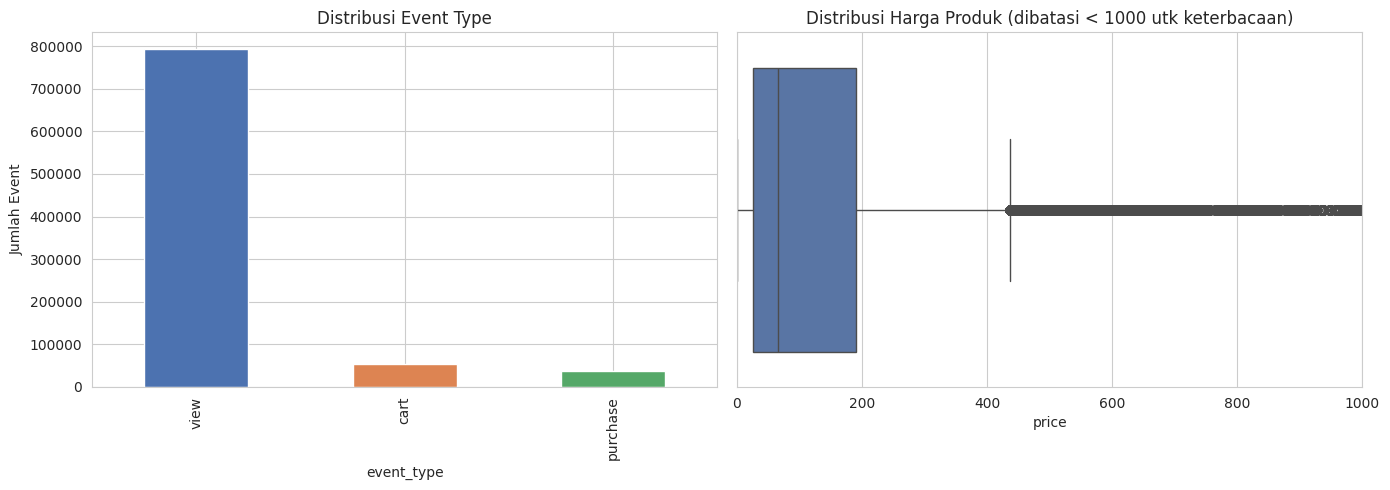

In [9]:
fig, axes = plt.subplots(1,2, figsize=(14,5))

df['event_type'].value_counts().plot(kind='bar', ax=axes[0], color=['#4C72B0','#DD8452','#55A868'])
axes[0].set_title('Distribusi Event Type')
axes[0].set_ylabel('Jumlah Event')

sns.boxplot(x=df['price'], ax=axes[1], color='#4C72B0')
axes[1].set_xlim(0, 1000)
axes[1].set_title('Distribusi Harga Produk (dibatasi < 1000 utk keterbacaan)')

plt.tight_layout()
plt.savefig('chart_distribusi.png', dpi=120)
plt.show()


### 3.2 Analisis Funnel Konversi (View → Cart → Purchase)

View -> Cart      : 8.45%
Cart -> Purchase  : 58.99%
View -> Purchase  : 4.98%


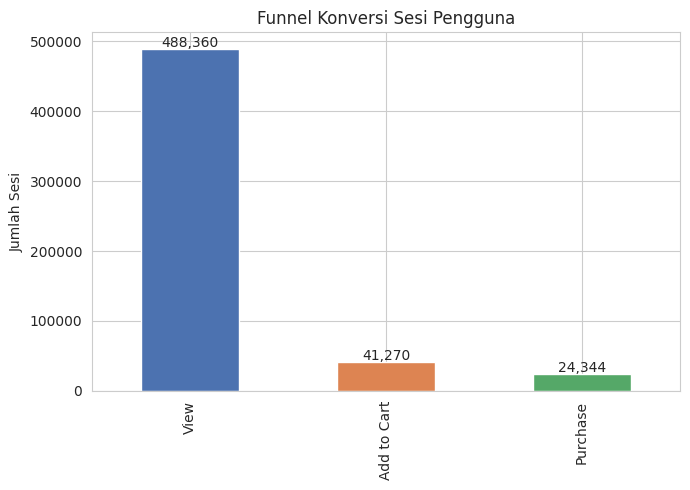

In [10]:
sessions_events = df.groupby('user_session')['event_type'].apply(set)
n_view = sessions_events.apply(lambda s: 'view' in s).sum()
n_cart = sessions_events.apply(lambda s: 'cart' in s).sum()
n_purchase = sessions_events.apply(lambda s: 'purchase' in s).sum()

funnel = pd.Series({'View': n_view, 'Add to Cart': n_cart, 'Purchase': n_purchase})
conv_view_cart = n_cart/n_view*100
conv_cart_purchase = n_purchase/n_cart*100
conv_view_purchase = n_purchase/n_view*100

print(f'View -> Cart      : {conv_view_cart:.2f}%')
print(f'Cart -> Purchase  : {conv_cart_purchase:.2f}%')
print(f'View -> Purchase  : {conv_view_purchase:.2f}%')

plt.figure(figsize=(7,5))
funnel.plot(kind='bar', color=['#4C72B0','#DD8452','#55A868'])
plt.title('Funnel Konversi Sesi Pengguna')
plt.ylabel('Jumlah Sesi')
for i, v in enumerate(funnel):
    plt.text(i, v+3000, f'{v:,}', ha='center')
plt.tight_layout()
plt.savefig('chart_funnel.png', dpi=120)
plt.show()


### 3.3 Cart Abandonment

Cart abandonment rate: 46.88%

                 mean  median  count
status                              
Abandoned  171.123934   96.23  25328
Converted  149.530757   73.81  28698


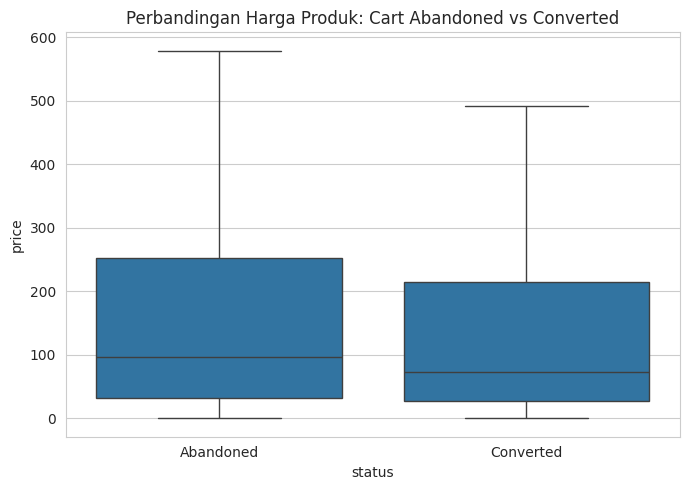

In [11]:
cart_df = df[df['event_type']=='cart'].copy()
purchase_sessions = set(df[df['event_type']=='purchase']['user_session'])
cart_df['status'] = cart_df['user_session'].isin(purchase_sessions).map({True:'Converted', False:'Abandoned'})

abandonment_rate = (cart_df['status']=='Abandoned').mean()*100
print(f'Cart abandonment rate: {abandonment_rate:.2f}%')
print()
print(cart_df.groupby('status')['price'].agg(['mean','median','count']))

plt.figure(figsize=(7,5))
sns.boxplot(data=cart_df, x='status', y='price', showfliers=False)
plt.title('Perbandingan Harga Produk: Cart Abandoned vs Converted')
plt.tight_layout()
plt.savefig('chart_abandonment.png', dpi=120)
plt.show()


### 3.4 Kategori & Brand Terlaris

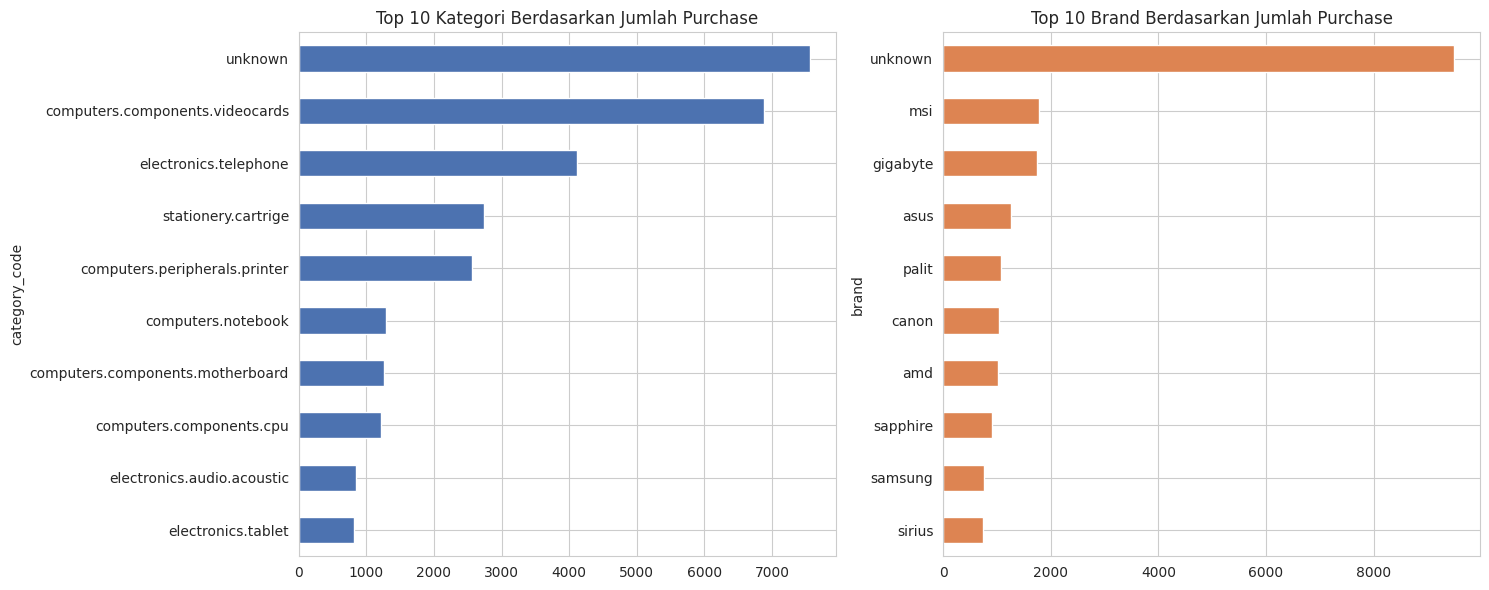

In [12]:
top_cat_purchase = df[df['event_type']=='purchase'].groupby('category_code').size().sort_values(ascending=False).head(10)
top_brand_purchase = df[df['event_type']=='purchase'].groupby('brand').size().sort_values(ascending=False).head(10)

fig, axes = plt.subplots(1,2, figsize=(15,6))
top_cat_purchase.sort_values().plot(kind='barh', ax=axes[0], color='#4C72B0')
axes[0].set_title('Top 10 Kategori Berdasarkan Jumlah Purchase')

top_brand_purchase.sort_values().plot(kind='barh', ax=axes[1], color='#DD8452')
axes[1].set_title('Top 10 Brand Berdasarkan Jumlah Purchase')

plt.tight_layout()
plt.savefig('chart_top_kategori_brand.png', dpi=120)
plt.show()


Total revenue tercatat: $5,125,113.92

category_code
computers.components.videocards     2604764.80
unknown                              493896.91
computers.peripherals.printer        364566.80
computers.components.cpu             219168.98
electronics.telephone                150915.69
stationery.cartrige                  103595.99
computers.components.motherboard     102871.16
electronics.audio.acoustic            84724.80
auto.accessories.player               81558.66
computers.notebook                    63604.79
Name: price, dtype: float64


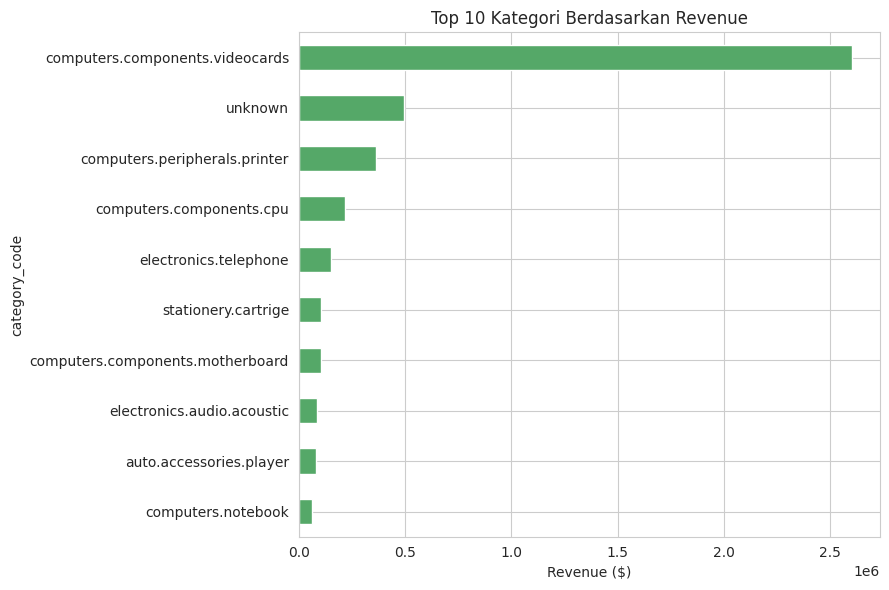

In [13]:
rev_by_cat = df[df['event_type']=='purchase'].groupby('category_code')['price'].sum().sort_values(ascending=False).head(10)
total_revenue = df[df['event_type']=='purchase']['price'].sum()
print(f'Total revenue tercatat: ${total_revenue:,.2f}')
print()
print(rev_by_cat)

plt.figure(figsize=(9,6))
rev_by_cat.sort_values().plot(kind='barh', color='#55A868')
plt.title('Top 10 Kategori Berdasarkan Revenue')
plt.xlabel('Revenue ($)')
plt.tight_layout()
plt.savefig('chart_revenue_kategori.png', dpi=120)
plt.show()


### 3.5 Pola Waktu (Trend)

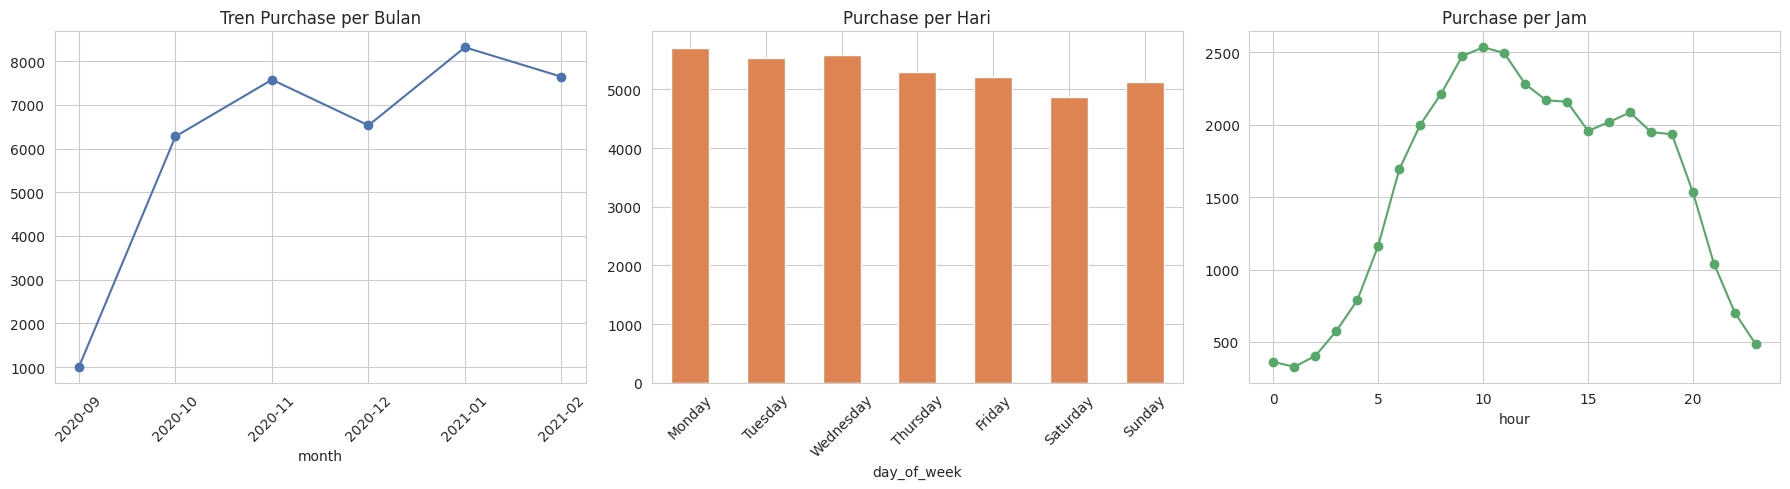

In [14]:
fig, axes = plt.subplots(1,3, figsize=(18,5))

df[df['event_type']=='purchase'].groupby('month').size().plot(kind='line', marker='o', ax=axes[0], color='#4C72B0')
axes[0].set_title('Tren Purchase per Bulan')
axes[0].tick_params(axis='x', rotation=45)

order_days = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
df[df['event_type']=='purchase'].groupby('day_of_week').size().reindex(order_days).plot(kind='bar', ax=axes[1], color='#DD8452')
axes[1].set_title('Purchase per Hari')
axes[1].tick_params(axis='x', rotation=45)

df[df['event_type']=='purchase'].groupby('hour').size().plot(kind='line', marker='o', ax=axes[2], color='#55A868')
axes[2].set_title('Purchase per Jam')

plt.tight_layout()
plt.savefig('chart_time_trend.png', dpi=120)
plt.show()


### 3.6 Hubungan Segmen Harga dengan Konversi (Heatmap)

event_type     cart  purchase   view
price_segment                       
Low            5.32      4.28  90.40
Medium         5.62      4.25  90.13
High           5.66      3.86  90.48
Premium        7.84      4.50  87.66


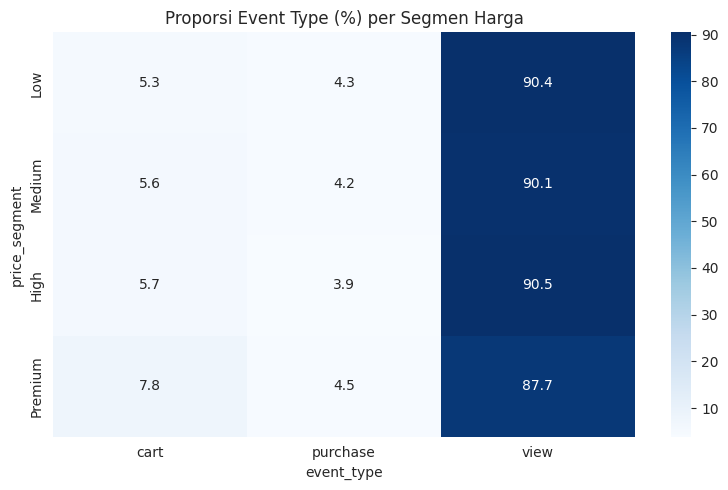

In [15]:
conv_table = pd.crosstab(df['price_segment'], df['event_type'], normalize='index') * 100
print(conv_table.round(2))

plt.figure(figsize=(8,5))
sns.heatmap(conv_table, annot=True, fmt='.1f', cmap='Blues')
plt.title('Proporsi Event Type (%) per Segmen Harga')
plt.tight_layout()
plt.savefig('chart_heatmap_price_segment.png', dpi=120)
plt.show()


## Tahap 4: Insight & Interpretasi

Berdasarkan hasil EDA di atas:

1. **Funnel konversi sangat bocor di tahap awal.** Dari seluruh sesi yang melakukan view,
   hanya ~8.5% yang add-to-cart, dan hanya ~5% dari total sesi view yang akhirnya purchase.
   Ini menunjukkan mayoritas pengunjung berhenti di tahap browsing — titik kritis untuk
   optimasi ada di **view → cart**, bukan di cart → purchase (yang justru cukup baik, ~59%).

2. **Cart abandonment tinggi (~47%)**, dan produk yang di-abandon rata-rata **lebih mahal**
   (~171 vs ~150 untuk yang converted). Ini mengindikasikan sensitivitas harga adalah faktor
   signifikan dalam keputusan checkout akhir.

3. **Kategori `computers.components.videocards` mendominasi baik jumlah purchase maupun
   revenue** (kontribusi revenue terbesar, jauh di atas kategori lain) — kemungkinan didorong
   oleh tren GPU shortage/harga tinggi periode 2020-2021. Brand seperti MSI, Gigabyte, Asus,
   Palit konsisten masuk top brand terlaris, sejalan dengan dominasi kategori komponen PC.

4. **Pola waktu jelas:** purchase memuncak pada jam kerja (9–12 siang), hari kerja
   (Senin–Rabu) lebih tinggi dari akhir pekan, dan tren bulanan naik menjelang
   Nov–Des (kemungkinan momentum promo/liburan) lalu naik lagi Jan 2021.

5. **Segmen harga Premium memiliki proporsi purchase relatif lebih kecil dibanding proporsi
   view-nya** dibanding segmen Low/Medium — mengonfirmasi bahwa harga tinggi memperbesar
   friksi konversi.


## Tahap 6: Rekomendasi Bisnis

1. **Optimasi tahap "view → cart"** (titik funnel paling bocor): perbaiki halaman produk
   (foto, deskripsi, review, perbandingan harga) dan tambahkan CTA/rekomendasi produk serupa
   yang lebih murah untuk kategori dengan harga tinggi, karena di sinilah 91.5% calon pembeli
   hilang.

2. **Program retargeting/reminder untuk cart abandonment**, khususnya untuk item di segmen
   harga Premium/High — misalnya email/notifikasi diskon terbatas waktu atau cicilan 0%,
   karena harga adalah faktor abandonment utama yang teridentifikasi.

3. **Fokuskan stok & promosi pada kategori `computers.components.videocards` dan brand top
   (MSI, Gigabyte, Asus, Palit)** karena kontribusinya dominan terhadap revenue — pastikan
   ketersediaan stok terjaga terutama menjelang periode puncak (Nov–Jan).

4. **Jadwalkan kampanye promosi/flash sale pada jam 9–12 siang di hari kerja (Senin–Rabu)**
   sesuai pola waktu purchase tertinggi, untuk memaksimalkan konversi dari traffic yang
   memang sudah lebih siap membeli di jam tersebut.

5. **Bundling atau cicilan untuk produk di price_segment Premium** guna menurunkan friksi
   psikologis harga tinggi, mengingat proporsi purchase di segmen ini lebih rendah
   dibanding proporsi view-nya.


In [16]:
df.to_csv('events_cleaned.csv', index=False)
from google.colab import files
files.download('events_cleaned.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>